## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import random
import json
import os
import warnings
warnings.filterwarnings('ignore')

import joblib
import statsmodels.stats.api as sms

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    roc_curve, auc, precision_recall_curve,
    confusion_matrix, recall_score, matthews_corrcoef
)

from xgboost import XGBClassifier

import optuna
import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

In [3]:
SEED_VALUE = 42
np.random.seed(SEED_VALUE)
random.seed(SEED_VALUE)

N_SPLITS = 5
DATA_DIR = '../Data'

print(f"Seed: {SEED_VALUE}, Folds: {N_SPLITS}")

Seed: 42, Folds: 5


## 3. Data Loading

In [4]:
df = pd.read_csv(f'{DATA_DIR}/final_dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns ({len(df.columns)}):")
print(df.columns.tolist())
df.head()

Dataset shape: (195440, 41)
Columns (41):
['stay_id', 'cam_bin', 'CAM-ICU', 'age', 'gender', 'los', 'Heart Rate_mean', 'Mean BP_mean', 'Oxygen Saturation_mean', 'Temperature_mean', 'Heart Rate_std', 'Mean BP_std', 'Oxygen Saturation_std', 'Temperature_std', 'Propofol', 'Opiates', 'Benzodiazepines', 'Ketamine', 'Vasopressors', 'Ventilator', 'Weight', 'RASS', 'WBC', 'Hemoglobin', 'Hematocrit', 'Platelets', 'Sodium', 'Potassium', 'Chloride', 'Bicarbonate', 'Calcium', 'Magnesium', 'Phosphate', 'BUN', 'Creatinine', 'ALT', 'Glucose', 'Lactate', 'pH', 'pCO2', 'pO2']


,stay_id,cam_bin,CAM-ICU,age,gender,los,Heart Rate_mean,Mean BP_mean,Oxygen Saturation_mean,Temperature_mean,...,Magnesium,Phosphate,BUN,Creatinine,ALT,Glucose,Lactate,pH,pCO2,pO2
0,30004018,27,0.0,56,1,16.094329,88.750,68.000,99.625,36.930556,...,2.4,4.9,66.0,3.7,71.0,102.0,0.6,7.27,52.0,120.0
1,30004018,74,0.0,56,1,16.094329,102.250,77.250,98.000,37.284722,...,2.4,5.9,86.0,5.2,52.0,69.0,1.5,7.34,41.0,91.0
2,30004018,82,0.0,56,1,16.094329,102.375,65.625,97.250,37.340278,...,2.1,4.6,47.0,3.5,49.0,78.0,1.5,7.34,41.0,91.0
3,30004018,106,0.0,56,1,16.094329,95.250,73.500,97.125,37.020833,...,2.2,4.9,52.0,3.6,47.0,66.0,1.5,7.34,41.0,91.0
4,30004018,142,0.0,56,1,16.094329,122.125,83.875,98.750,36.861111,...,2.1,3.9,30.0,2.7,48.0,65.0,0.7,7.27,56.0,53.0


## 4. Data Exploration

| Group | Columns | Aggregation |
|-------|---------|-------------|
| Demographics | age, gender, los | First value |
| Vital Signs | Heart Rate, Mean BP, O2 Sat, Temperature | 8h mean + std |
| Drugs/Equipment | Propofol, Opiates, Benzodiazepines, Ketamine, Vasopressors, Ventilator | Binary (1/0) |
| Consciousness | RASS | Latest value |
| Body Measurement | Weight | Latest value |
| Lab Tests | WBC, Hemoglobin, ... , pO2 | Latest value |
| **Target** | **CAM-ICU** | **0/1** |

In [5]:
print(f"Unique stays: {df['stay_id'].nunique()}")

print(f"\n=== Sample-level CAM-ICU Distribution ===")
print(df['CAM-ICU'].value_counts())
print(f"Positive rate: {df['CAM-ICU'].mean()*100:.2f}%")

patient_labels_check = df.groupby('stay_id')['CAM-ICU'].max()
n_pos_patients = (patient_labels_check == 1).sum()
n_neg_patients = (patient_labels_check == 0).sum()
print(f"\n=== Patient-level Distribution ===")
print(f"Positive (ever delirious): {n_pos_patients}")
print(f"Negative (never delirious): {n_neg_patients}")
print(f"Patient-level positive rate: {n_pos_patients / len(patient_labels_check) * 100:.2f}%")

Unique stays: 7644

=== Sample-level CAM-ICU Distribution ===
CAM-ICU
0.0    188739
1.0      6701
Name: count, dtype: int64
Positive rate: 3.43%

=== Patient-level Distribution ===
Positive (ever delirious): 2437
Negative (never delirious): 5207
Patient-level positive rate: 31.88%


## 5. Class Weighting

- LR, RF: `class_weight='balanced'` → sklearn이 자동으로 `n_samples / (n_classes * n_samples_per_class)` 계산
- XGB: `scale_pos_weight = n_negative / n_positive` (동일한 효과)

In [6]:
neg_count = int((df['CAM-ICU'] == 0).sum())
pos_count = int((df['CAM-ICU'] == 1).sum())
balanced_w0 = len(df) / (2 * neg_count)
balanced_w1 = len(df) / (2 * pos_count)

print(f"Class weights (balanced):")
print(f"  Class 0 (No Delirium): weight={  balanced_w0:.4f}, count={neg_count:,}")
print(f"  Class 1 (Delirium):    weight={balanced_w1:.4f}, count={pos_count:,}")
print(f"  Ratio (w1/w0): {balanced_w1/balanced_w0:.1f}x")

Class weights (balanced):
  Class 0 (No Delirium): weight=0.5178, count=188,739
  Class 1 (Delirium):    weight=14.5829, count=6,701
  Ratio (w1/w0): 28.2x


# 6. Data Split

In [7]:
FEATURE_COLS = [col for col in df.columns if col not in ['stay_id', 'cam_bin', 'CAM-ICU', 'los']]
TARGET_COL = 'CAM-ICU'

In [8]:
X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].values

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED_VALUE, stratify=y
)

print(f"Train: {len(y_train):,} (pos={y_train.sum():.0f}, {y_train.mean()*100:.2f}%)")
print(f"Test:  {len(y_test):,} (pos={y_test.sum():.0f}, {y_test.mean()*100:.2f}%)")


Train: 156,352 (pos=5361, 3.43%)
Test:  39,088 (pos=1340, 3.43%)


# 7. Outlier 제거 & Imputation

In [9]:
# 바이너리/범주형 컬럼 제외 (0/1 만 존재하는 컬럼)
non_null_uniques = {col: set(X_train[col].dropna().unique()) for col in X_train.columns}
binary_cols = [
    col for col, vals in non_null_uniques.items()
    if len(vals) <= 2 and vals.issubset({0, 1})
]

# 연속형 컬럼만 outlier 처리 대상
continuous_cols = [col for col in X_train.columns if col not in binary_cols]

# Imputation (train 기준)
# Outlier를 NaN으로 치환 (train 기준 0.5~99.5 percentile)
percentile_low = 0.001
percentile_high = 0.999

bounds = {}
for col in continuous_cols:
    q_low = X_train[col].quantile(percentile_low)
    q_high = X_train[col].quantile(percentile_high)
    bounds[col] = (q_low, q_high)

# train/test 동일 경계 적용
for col, (q_low, q_high) in bounds.items():
    X_train.loc[(X_train[col] < q_low) | (X_train[col] > q_high), col] = np.nan
    X_test.loc[(X_test[col] < q_low) | (X_test[col] > q_high), col] = np.nan

print(f"Outlier 처리 완료 (percentile {percentile_low*100:.1f}~{percentile_high*100:.1f})")
print(f"  Continuous cols: {len(continuous_cols)}")
print(f"  Binary cols excluded: {len(binary_cols)}")

Outlier 처리 완료 (percentile 0.1~99.9)
  Continuous cols: 31
  Binary cols excluded: 6


In [10]:
# Imputation
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

print(f"\nImputation 완료 (train 기준 median)")
print(f"X_train: {X_train.shape}, NaN={np.isnan(X_train).sum()}")
print(f"X_test: {X_test.shape}, NaN={np.isnan(X_test).sum()}")


Imputation 완료 (train 기준 median)
X_train: (156352, 37), NaN=0
X_test: (39088, 37), NaN=0


## 8. Hyperparameter Tuning (Optuna)

In [11]:
N_TRIALS = 8
N_JOBS = 4

OPTUNA_SAVE_DIR = '../models/optuna'
os.makedirs(OPTUNA_SAVE_DIR, exist_ok=True)

kfold = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED_VALUE)

def cv_auprc_for_model(model_builder, needs_scaling=False):
    scores = []
    for tr_idx, val_idx in kfold.split(X_train, y_train):
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]

        if needs_scaling:
            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr)
            X_val = scaler.transform(X_val)

        clf = model_builder()
        clf.fit(X_tr, y_tr)
        probs = clf.predict_proba(X_val)[:, 1]
        scores.append(average_precision_score(y_val, probs))
    return float(np.mean(scores))

In [12]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, x):
        return self.net(x)


def train_mlp_fold(X_tr, y_tr, X_val, y_val,
                   hidden_dim=256, dropout=0.3, lr=1e-3,
                   epochs=20, batch_size=512):
    """Train MLP on a single fold and return validation probabilities."""
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_val_s = scaler.transform(X_val)

    X_tr_t = torch.tensor(X_tr_s, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32).view(-1, 1)
    X_val_t = torch.tensor(X_val_s, dtype=torch.float32)

    model = MLP(X_tr_t.shape[1], hidden_dim, dropout)

    pos = (y_tr == 1).sum()
    neg = (y_tr == 0).sum()
    pos_weight = torch.tensor([neg / max(pos, 1)], dtype=torch.float32)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    model.train()
    for epoch in range(epochs):
        perm = torch.randperm(len(X_tr_t))
        for i in range(0, len(X_tr_t), batch_size):
            idx = perm[i:i + batch_size]
            optimizer.zero_grad()
            loss = criterion(model(X_tr_t[idx]), y_tr_t[idx])
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X_val_t)).numpy().ravel()

    return probs

print("MLP class and train_mlp_fold defined")

MLP class and train_mlp_fold defined


In [51]:
# ---- 1) Logistic Regression ----
print("=" * 60)
print("OPTUNA: LOGISTIC REGRESSION (AUPRC)")
print("=" * 60)

def objective_lr(trial):
    C = trial.suggest_float('C', 0.01, 100.0, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    solver = 'liblinear'

    def builder():
        return LogisticRegression(
            random_state=SEED_VALUE,
            solver=solver,
            penalty=penalty,
            C=C,
            class_weight='balanced',
        )

    return cv_auprc_for_model(builder, needs_scaling=True)

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=N_TRIALS, n_jobs=N_JOBS)
print("Best LR params:", study_lr.best_params)
print("Best LR AUPRC:", study_lr.best_value)

# Save LR best params
with open(f"{OPTUNA_SAVE_DIR}/best_params_LR.json", "w") as f:
    json.dump({"params": study_lr.best_params, "best_value": study_lr.best_value}, f, indent=2)
print(f"LR best params saved to {OPTUNA_SAVE_DIR}/best_params_LR.json")


[I 2026-02-05 09:01:31,887] A new study created in memory with name: no-name-1fb334b9-eaa9-42b7-b6d7-6a739c09457e


OPTUNA: LOGISTIC REGRESSION (AUPRC)


[I 2026-02-05 09:01:56,321] Trial 3 finished with value: 0.1053921614934576 and parameters: {'C': 0.015376634892537383, 'penalty': 'l1'}. Best is trial 3 with value: 0.1053921614934576.
[I 2026-02-05 09:01:57,848] Trial 2 finished with value: 0.1062104543374555 and parameters: {'C': 0.06765981854834734, 'penalty': 'l1'}. Best is trial 2 with value: 0.1062104543374555.
[I 2026-02-05 09:01:58,531] Trial 1 finished with value: 0.10623209088878885 and parameters: {'C': 0.07462845760266856, 'penalty': 'l1'}. Best is trial 1 with value: 0.10623209088878885.
[I 2026-02-05 09:01:59,647] Trial 0 finished with value: 0.10641922274940958 and parameters: {'C': 0.6241943289823065, 'penalty': 'l1'}. Best is trial 0 with value: 0.10641922274940958.
[I 2026-02-05 09:02:10,788] Trial 5 finished with value: 0.10525882076943412 and parameters: {'C': 0.13277267452615954, 'penalty': 'l2'}. Best is trial 0 with value: 0.10641922274940958.
[I 2026-02-05 09:02:12,572] Trial 7 finished with value: 0.1063727676

Best LR params: {'C': 9.854005754971757, 'penalty': 'l1'}
Best LR AUPRC: 0.10644617769347328


In [14]:
# ---- 2) Random Forest ----
print("=" * 60)
print("OPTUNA: RANDOM FOREST (AUPRC)")
print("=" * 60)

def objective_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 500)
    max_depth = trial.suggest_int('max_depth', 10, 30)
    min_samples_split = trial.suggest_categorical('min_samples_split', [2, 5, 10])

    def builder():
        return RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            random_state=SEED_VALUE,
            max_features=8,
            class_weight='balanced',
            n_jobs=-1,
        )

    return cv_auprc_for_model(builder, needs_scaling=False)

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=N_TRIALS, n_jobs=N_JOBS)
print("Best RF params:", study_rf.best_params)
print("Best RF AUPRC:", study_rf.best_value)

# Save RF best params
with open(f"{OPTUNA_SAVE_DIR}/best_params_RF.json", "w") as f:
    json.dump({"params": study_rf.best_params, "best_value": study_rf.best_value}, f, indent=2)
print(f"RF best params saved to {OPTUNA_SAVE_DIR}/best_params_RF.json")


[I 2026-02-05 09:59:54,555] A new study created in memory with name: no-name-ca2b3c19-d4ee-435e-b4dc-b8909e057f73


OPTUNA: RANDOM FOREST (AUPRC)


[I 2026-02-05 10:02:39,913] Trial 0 finished with value: 0.42008243797327066 and parameters: {'n_estimators': 369, 'max_depth': 14, 'min_samples_split': 2}. Best is trial 0 with value: 0.42008243797327066.
[I 2026-02-05 10:05:51,705] Trial 1 finished with value: 0.4319142499221237 and parameters: {'n_estimators': 386, 'max_depth': 24, 'min_samples_split': 2}. Best is trial 1 with value: 0.4319142499221237.
[I 2026-02-05 10:08:09,302] Trial 2 finished with value: 0.42102520217092304 and parameters: {'n_estimators': 295, 'max_depth': 17, 'min_samples_split': 2}. Best is trial 1 with value: 0.4319142499221237.
[I 2026-02-05 10:11:48,313] Trial 3 finished with value: 0.42664076203449597 and parameters: {'n_estimators': 467, 'max_depth': 19, 'min_samples_split': 10}. Best is trial 1 with value: 0.4319142499221237.
[I 2026-02-05 10:15:33,130] Trial 4 finished with value: 0.42355302704954473 and parameters: {'n_estimators': 461, 'max_depth': 18, 'min_samples_split': 10}. Best is trial 1 with 

Best RF params: {'n_estimators': 447, 'max_depth': 25, 'min_samples_split': 2}
Best RF AUPRC: 0.433377957488703
RF best params saved to ../models/optuna/best_params_RF.json


In [13]:
# ---- 3) XGBoost ----
print("=" * 60)
print("OPTUNA: XGBOOST (AUPRC)")
print("=" * 60)

def objective_xgb(trial):
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2, log=True)
    max_depth = trial.suggest_int('max_depth', 3, 9)
    subsample = trial.suggest_float('subsample', 0.6, 1.0)

    scores = []
    for tr_idx, val_idx in kfold.split(X_train, y_train):
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]

        neg = (y_tr == 0).sum()
        pos = (y_tr == 1).sum()
        clf = XGBClassifier(
            n_estimators=300,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            random_state=SEED_VALUE,
            scale_pos_weight=neg / pos,
            use_label_encoder=False,
            eval_metric='logloss',
        )
        clf.fit(X_tr, y_tr)
        probs = clf.predict_proba(X_val)[:, 1]
        scores.append(average_precision_score(y_val, probs))

    return float(np.mean(scores))

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, n_jobs=N_JOBS)
print("Best XGB params:", study_xgb.best_params)
print("Best XGB AUPRC:", study_xgb.best_value)

# Save XGB best params
with open(f"{OPTUNA_SAVE_DIR}/best_params_XGB.json", "w") as f:
    json.dump({"params": study_xgb.best_params, "best_value": study_xgb.best_value}, f, indent=2)
print(f"XGB best params saved to {OPTUNA_SAVE_DIR}/best_params_XGB.json")


[I 2026-02-05 09:57:51,600] A new study created in memory with name: no-name-28fcbbd5-5efe-486e-9db5-6014d105b1f6


OPTUNA: XGBOOST (AUPRC)


[I 2026-02-05 09:58:05,586] Trial 0 finished with value: 0.48180685577838533 and parameters: {'learning_rate': 0.043145016425973744, 'max_depth': 7, 'subsample': 0.685328221341916}. Best is trial 0 with value: 0.48180685577838533.
[I 2026-02-05 09:58:14,499] Trial 1 finished with value: 0.4597215203306154 and parameters: {'learning_rate': 0.0758066510804924, 'max_depth': 5, 'subsample': 0.6299066873712714}. Best is trial 0 with value: 0.48180685577838533.
[I 2026-02-05 09:58:35,484] Trial 2 finished with value: 0.46944468758651475 and parameters: {'learning_rate': 0.01403189994923293, 'max_depth': 9, 'subsample': 0.779623967647096}. Best is trial 0 with value: 0.48180685577838533.
[I 2026-02-05 09:58:41,067] Trial 3 finished with value: 0.4328360782126722 and parameters: {'learning_rate': 0.100060545606764, 'max_depth': 3, 'subsample': 0.9409204717610895}. Best is trial 0 with value: 0.48180685577838533.
[I 2026-02-05 09:58:57,524] Trial 4 finished with value: 0.49267903947063346 and p

Best XGB params: {'learning_rate': 0.07867230112668629, 'max_depth': 8, 'subsample': 0.7733471156447138}
Best XGB AUPRC: 0.5072214987369308
XGB best params saved to ../models/optuna/best_params_XGB.json


In [12]:
# ---- 4) MLP ----
print("=" * 60)
print("OPTUNA: MLP (AUPRC)")
print("=" * 60)

def objective_mlp(trial):
    hidden_dim = trial.suggest_categorical('hidden_dim', [128, 256, 512])
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

    scores = []
    for tr_idx, val_idx in kfold.split(X_train, y_train):
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]

        probs = train_mlp_fold(
            X_tr, y_tr, X_val, y_val,
            hidden_dim=hidden_dim, dropout=dropout, lr=lr,
            epochs=15,
        )
        scores.append(average_precision_score(y_val, probs))

    return float(np.mean(scores))

study_mlp = optuna.create_study(direction='maximize')
study_mlp.optimize(objective_mlp, n_trials=N_TRIALS, n_jobs=1)
print("Best MLP params:", study_mlp.best_params)
print("Best MLP AUPRC:", study_mlp.best_value)

# Save MLP best params
with open(f"{OPTUNA_SAVE_DIR}/best_params_MLP.json", "w") as f:
    json.dump({"params": study_mlp.best_params, "best_value": study_mlp.best_value}, f, indent=2)
print(f"MLP best params saved to {OPTUNA_SAVE_DIR}/best_params_MLP.json")


[I 2026-02-05 09:44:59,451] A new study created in memory with name: no-name-10954dc2-5ac3-46cc-b0fb-9b6b3f4dbe46


OPTUNA: MLP (AUPRC)


[I 2026-02-05 09:47:14,890] Trial 0 finished with value: 0.1489721375657679 and parameters: {'hidden_dim': 256, 'dropout': 0.46500229465138, 'lr': 0.0002877671389860887}. Best is trial 0 with value: 0.1489721375657679.
[I 2026-02-05 09:48:18,335] Trial 1 finished with value: 0.15619927706998266 and parameters: {'hidden_dim': 128, 'dropout': 0.3076789181795992, 'lr': 0.0004382490076061277}. Best is trial 1 with value: 0.15619927706998266.
[I 2026-02-05 09:49:27,549] Trial 2 finished with value: 0.15148262026007525 and parameters: {'hidden_dim': 128, 'dropout': 0.29361475842744833, 'lr': 0.0003402020042980259}. Best is trial 1 with value: 0.15619927706998266.
[I 2026-02-05 09:51:21,570] Trial 3 finished with value: 0.16098660757442063 and parameters: {'hidden_dim': 256, 'dropout': 0.3933185461885019, 'lr': 0.006937351777897723}. Best is trial 3 with value: 0.16098660757442063.
[I 2026-02-05 09:52:36,045] Trial 4 finished with value: 0.17034712596358814 and parameters: {'hidden_dim': 128,

Best MLP params: {'hidden_dim': 128, 'dropout': 0.4431090881945525, 'lr': 0.0025787981308427704}
Best MLP AUPRC: 0.17034712596358814
MLP best params saved to ../models/optuna/best_params_MLP.json


## 9. Helper Functions

In [13]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    """Compute classification metrics for a single fold."""
    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = auc(fpr, tpr)

    # Precision-Recall
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)
    auc_prc = average_precision_score(y_true, y_prob)

    # Confusion matrix metrics
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    ppv = tp / max(tp + fp, 1)
    npv = tn / max(tn + fn, 1)
    sensitivity = tp / max(tp + fn, 1)
    specificity = tn / max(tn + fp, 1)
    mcc = matthews_corrcoef(y_true, y_pred)

    # Specificity at 90% sensitivity
    idx_90 = np.argmin(np.abs(tpr - 0.90))
    spec_at_90 = 1 - fpr[idx_90]

    return {
        'auc': auc_val,
        'auc_prc': auc_prc,
        'ppv': ppv,
        'npv': npv,
        'mcc': mcc,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'spec@90': spec_at_90,
        'fpr': fpr,
        'tpr': tpr,
        'precision_curve': precision_curve,
        'recall_curve': recall_curve,
    }


def aggregate_cv_metrics(cv_dict):
    """Aggregate metrics across CV folds with 95% CI."""
    aucs = [m['auc'] for m in cv_dict.values()]
    auprcs = [m['auc_prc'] for m in cv_dict.values()]
    ppvs = [m['ppv'] for m in cv_dict.values()]
    npvs = [m['npv'] for m in cv_dict.values()]
    mccs = [m['mcc'] for m in cv_dict.values()]
    specs90 = [m['spec@90'] for m in cv_dict.values()]
    recalls = [m['sensitivity'] for m in cv_dict.values()]

    mean_fpr = np.linspace(0, 1, 100)
    mean_recall_pts = np.linspace(0, 1, 100)

    # Interpolate ROC curves
    tprs = []
    for m in cv_dict.values():
        interp_tpr = np.interp(mean_fpr, m['fpr'], m['tpr'])
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0

    # Interpolate PR curves
    prcs = []
    for m in cv_dict.values():
        sorted_idx = np.argsort(m['recall_curve'])
        interp_prc = np.interp(
            mean_recall_pts,
            m['recall_curve'][sorted_idx],
            m['precision_curve'][sorted_idx],
        )
        prcs.append(interp_prc)
    mean_prc = np.mean(prcs, axis=0)

    def ci_95(values):
        lo, hi = sms.DescrStatsW(np.array(values)).tconfint_mean(alpha=0.05)
        return lo, hi

    auc_lo, auc_hi = ci_95(aucs)
    auprc_lo, auprc_hi = ci_95(auprcs)
    ppv_lo, ppv_hi = ci_95(ppvs)
    rec_lo, rec_hi = ci_95(recalls)

    return {
        'mean_auc': np.mean(aucs),
        'std_auc': np.std(aucs),
        'l_CI': auc_lo,
        'h_CI': auc_hi,
        'tpr': mean_tpr,
        'mean_auc_prc': np.mean(auprcs),
        'auprc_l_CI': auprc_lo,
        'auprc_h_CI': auprc_hi,
        'mean_prc': mean_prc,
        'ppv': np.mean(ppvs),
        'p_l_CI': ppv_lo,
        'p_h_CI': ppv_hi,
        'npv': np.mean(npvs),
        'mcc': np.mean(mccs),
        'spec@90': np.mean(specs90),
        'rec_single': np.mean(recalls),
        'r_l_CI': rec_lo,
        'r_h_CI': rec_hi,
    }

print("Helper functions defined: compute_metrics, aggregate_cv_metrics")

Helper functions defined: compute_metrics, aggregate_cv_metrics


## 10. K-Fold Cross Validation

In [14]:
kfold = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED_VALUE)

folds = []
for fold_idx, (tr_idx, val_idx) in enumerate(kfold.split(X_train, y_train), 1):
    folds.append({
        'fold': fold_idx,
        'X_tr': X_train[tr_idx],
        'X_val': X_train[val_idx],
        'y_tr': y_train[tr_idx],
        'y_val': y_train[val_idx],
    })
    print(
        f"Fold {fold_idx}: train {len(tr_idx):,} (pos={y_train[tr_idx].sum():.0f}) | "
        f"val {len(val_idx):,} (pos={y_train[val_idx].sum():.0f})"
    )
print(f"\n{len(folds)} folds ready")

Fold 1: train 125,081 (pos=4289) | val 31,271 (pos=1072)
Fold 2: train 125,081 (pos=4288) | val 31,271 (pos=1073)
Fold 3: train 125,082 (pos=4289) | val 31,270 (pos=1072)
Fold 4: train 125,082 (pos=4289) | val 31,270 (pos=1072)
Fold 5: train 125,082 (pos=4289) | val 31,270 (pos=1072)

5 folds ready


## 11. Cross Validation with Best Params

In [16]:
# ---- Load Optuna Best Params ----
model_names = ["LR", "RF", "XGB", "MLP"]
loaded_params = {}

for name in model_names:
    path = f"{OPTUNA_SAVE_DIR}/best_params_{name}.json"
    with open(path, "r") as f:
        loaded_params[name] = json.load(f)
    print(f"{name}: {loaded_params[name]['params']}  (AUPRC={loaded_params[name]['best_value']:.4f})")

best_lr_params = loaded_params["LR"]["params"]
best_rf_params = loaded_params["RF"]["params"]
best_xgb_params = loaded_params["XGB"]["params"]
best_mlp_params = loaded_params["MLP"]["params"]

print(f"Loaded best params from {OPTUNA_SAVE_DIR}/")


LR: {'C': 63.54274146482138, 'penalty': 'l1'}  (AUPRC=0.1064)
RF: {'n_estimators': 447, 'max_depth': 25, 'min_samples_split': 2}  (AUPRC=0.4334)
XGB: {'learning_rate': 0.07867230112668629, 'max_depth': 8, 'subsample': 0.7733471156447138}  (AUPRC=0.5072)
MLP: {'hidden_dim': 128, 'dropout': 0.4431090881945525, 'lr': 0.0025787981308427704}  (AUPRC=0.1703)
Loaded best params from ../models/optuna/


In [17]:
print("=" * 60)
print("LOGISTIC REGRESSION (Best Params from Optuna)")
print("=" * 60)

lr_cv = {}

for f in folds:
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(f['X_tr'])
    X_val = scaler.transform(f['X_val'])

    clf = LogisticRegression(
        random_state=SEED_VALUE,
        solver='liblinear',
        class_weight='balanced',
        **best_lr_params,
    )
    clf.fit(X_tr, f['y_tr'])
    probs = clf.predict_proba(X_val)[:, 1]

    lr_cv[f['fold']] = compute_metrics(f['y_val'], probs)
    m = lr_cv[f['fold']]
    print(
        f"Fold {f['fold']:2d}: AUC={m['auc']:.4f}  AUPRC={m['auc_prc']:.4f}  "
        f"PPV={m['ppv']:.4f}  NPV={m['npv']:.4f}  MCC={m['mcc']:.4f}"
    )

lr_results = aggregate_cv_metrics(lr_cv)

LOGISTIC REGRESSION (Best Params from Optuna)


Fold  1: AUC=0.8069  AUPRC=0.1068  PPV=0.0748  NPV=0.9918  MCC=0.1784
Fold  2: AUC=0.8031  AUPRC=0.1071  PPV=0.0748  NPV=0.9912  MCC=0.1767
Fold  3: AUC=0.8013  AUPRC=0.1012  PPV=0.0756  NPV=0.9916  MCC=0.1797
Fold  4: AUC=0.8078  AUPRC=0.1080  PPV=0.0757  NPV=0.9923  MCC=0.1822
Fold  5: AUC=0.8072  AUPRC=0.1091  PPV=0.0753  NPV=0.9919  MCC=0.1801


In [18]:
print("=" * 60)
print("RANDOM FOREST (Best Params from Optuna)")
print("=" * 60)

rf_cv = {}

for f in folds:
    clf = RandomForestClassifier(
        random_state=SEED_VALUE,
        max_features=8,
        class_weight='balanced',
        n_jobs=-1,
        **best_rf_params,
    )
    clf.fit(f['X_tr'], f['y_tr'])
    probs = clf.predict_proba(f['X_val'])[:, 1]

    rf_cv[f['fold']] = compute_metrics(f['y_val'], probs)
    m = rf_cv[f['fold']]
    print(
        f"Fold {f['fold']:2d}: AUC={m['auc']:.4f}  AUPRC={m['auc_prc']:.4f}  "
        f"PPV={m['ppv']:.4f}  NPV={m['npv']:.4f}  MCC={m['mcc']:.4f}"
    )

rf_results = aggregate_cv_metrics(rf_cv)

RANDOM FOREST (Best Params from Optuna)
Fold  1: AUC=0.9512  AUPRC=0.4093  PPV=0.3468  NPV=0.9922  MCC=0.5000
Fold  2: AUC=0.9584  AUPRC=0.4676  PPV=0.3770  NPV=0.9927  MCC=0.5281
Fold  3: AUC=0.9515  AUPRC=0.4373  PPV=0.3608  NPV=0.9921  MCC=0.5096
Fold  4: AUC=0.9563  AUPRC=0.4132  PPV=0.3511  NPV=0.9917  MCC=0.4986
Fold  5: AUC=0.9564  AUPRC=0.4395  PPV=0.3629  NPV=0.9919  MCC=0.5100


In [19]:
print("=" * 60)
print("XGBOOST (Best Params from Optuna)")
print("=" * 60)

xgb_cv = {}

for f in folds:
    neg = (f['y_tr'] == 0).sum()
    pos = (f['y_tr'] == 1).sum()

    clf = XGBClassifier(
        n_estimators=300,
        random_state=SEED_VALUE,
        scale_pos_weight=neg / pos,
        use_label_encoder=False,
        eval_metric='logloss',
        **best_xgb_params,
    )
    clf.fit(f['X_tr'], f['y_tr'])
    probs = clf.predict_proba(f['X_val'])[:, 1]

    xgb_cv[f['fold']] = compute_metrics(f['y_val'], probs)
    m = xgb_cv[f['fold']]
    print(
        f"Fold {f['fold']:2d}: AUC={m['auc']:.4f}  AUPRC={m['auc_prc']:.4f}  "
        f"PPV={m['ppv']:.4f}  NPV={m['npv']:.4f}  MCC={m['mcc']:.4f}"
    )

xgb_results = aggregate_cv_metrics(xgb_cv)

XGBOOST (Best Params from Optuna)
Fold  1: AUC=0.9574  AUPRC=0.4974  PPV=0.3965  NPV=0.9904  MCC=0.5197
Fold  2: AUC=0.9606  AUPRC=0.5323  PPV=0.4206  NPV=0.9911  MCC=0.5440
Fold  3: AUC=0.9603  AUPRC=0.5090  PPV=0.4036  NPV=0.9902  MCC=0.5227
Fold  4: AUC=0.9609  AUPRC=0.4999  PPV=0.4021  NPV=0.9907  MCC=0.5266
Fold  5: AUC=0.9617  AUPRC=0.4976  PPV=0.4063  NPV=0.9906  MCC=0.5286


In [20]:
print("=" * 60)
print("MLP (Best Params from Optuna)")
print("=" * 60)

mlp_cv = {}

for f in folds:
    probs = train_mlp_fold(
        f['X_tr'], f['y_tr'], f['X_val'], f['y_val'],
        epochs=20,
        **best_mlp_params,
    )

    mlp_cv[f['fold']] = compute_metrics(f['y_val'], probs)
    m = mlp_cv[f['fold']]
    print(
        f"Fold {f['fold']:2d}: AUC={m['auc']:.4f}  AUPRC={m['auc_prc']:.4f}  "
        f"PPV={m['ppv']:.4f}  NPV={m['npv']:.4f}  MCC={m['mcc']:.4f}"
    )

mlp_results = aggregate_cv_metrics(mlp_cv)

MLP (Best Params from Optuna)
Fold  1: AUC=0.8612  AUPRC=0.1806  PPV=0.0938  NPV=0.9939  MCC=0.2251
Fold  2: AUC=0.8655  AUPRC=0.1851  PPV=0.0978  NPV=0.9943  MCC=0.2340
Fold  3: AUC=0.8611  AUPRC=0.1689  PPV=0.1018  NPV=0.9927  MCC=0.2348
Fold  4: AUC=0.8641  AUPRC=0.1678  PPV=0.0983  NPV=0.9941  MCC=0.2343
Fold  5: AUC=0.8635  AUPRC=0.1821  PPV=0.1018  NPV=0.9933  MCC=0.2370


In [21]:
all_results = {'LR': lr_results, 'RF': rf_results, 'XGB': xgb_results, 'MLP': mlp_results}

for name, r in all_results.items():
    print(f"{name}: AUC={r['mean_auc']:.4f} ({r['l_CI']:.4f}-{r['h_CI']:.4f})  "
          f"AUPRC={r['mean_auc_prc']:.4f} ({r['auprc_l_CI']:.4f}-{r['auprc_h_CI']:.4f})")

LR: AUC=0.8052 (0.8017-0.8088)  AUPRC=0.1064 (0.1026-0.1103)
RF: AUC=0.9548 (0.9507-0.9588)  AUPRC=0.4334 (0.4042-0.4626)
XGB: AUC=0.9602 (0.9582-0.9622)  AUPRC=0.5072 (0.4888-0.5256)
MLP: AUC=0.8631 (0.8607-0.8655)  AUPRC=0.1769 (0.1670-0.1868)


## 12. Visualization

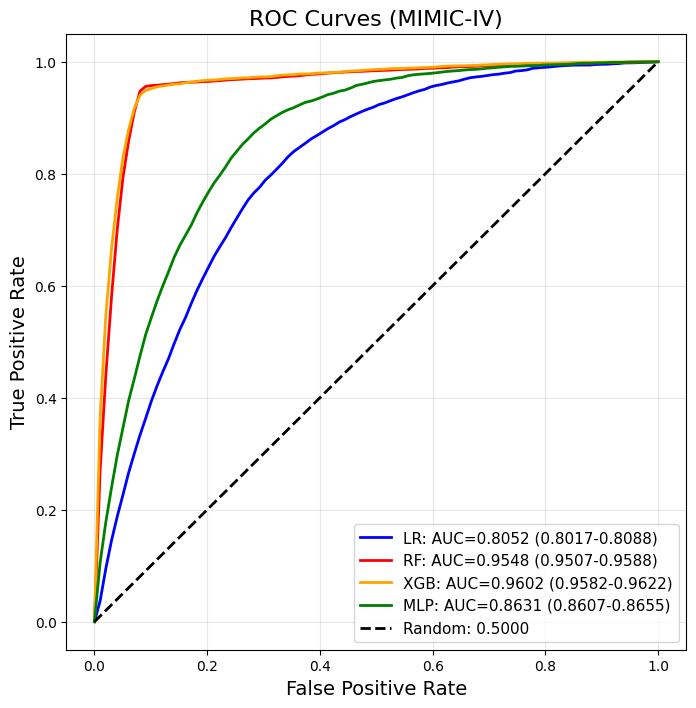

In [22]:
plt.figure(figsize=(8, 8))
mean_fpr = np.linspace(0, 1, 100)
colors = {'LR': 'b', 'RF': 'r', 'XGB': 'orange', 'MLP': 'green'}

for name, result in all_results.items():
    plt.plot(mean_fpr, result['tpr'],
             label=f"{name}: AUC={result['mean_auc']:.4f} ({result['l_CI']:.4f}-{result['h_CI']:.4f})",
             color=colors[name], lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random: 0.5000')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curves (MIMIC-IV)', fontsize=16)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.savefig('cv_mimiciv_roc.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

Baseline (positive ratio): 0.0343


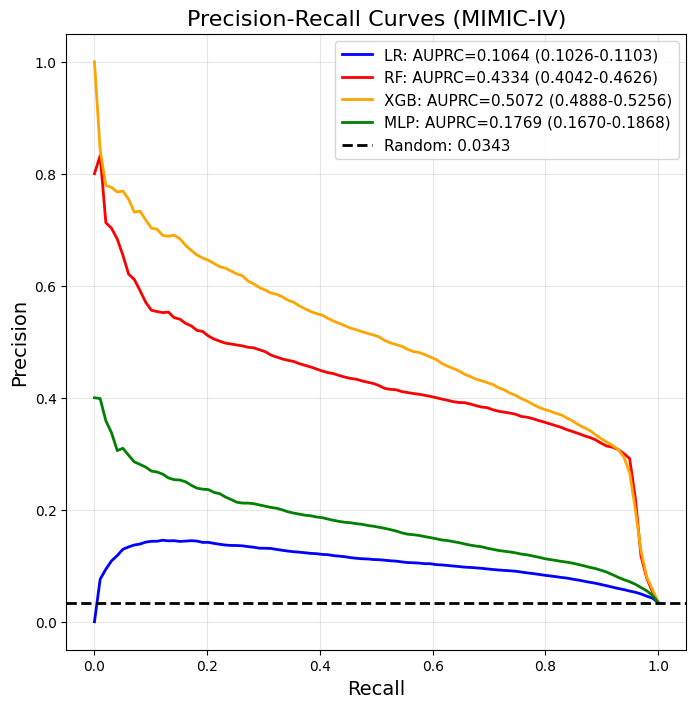

In [23]:
baseline_ratio = df[TARGET_COL].mean()
print(f"Baseline (positive ratio): {baseline_ratio:.4f}")

plt.figure(figsize=(8, 8))
mean_recall = np.linspace(0, 1, 100)

for name, result in all_results.items():
    plt.plot(mean_recall, result['mean_prc'],
             label=f"{name}: AUPRC={result['mean_auc_prc']:.4f} ({result['auprc_l_CI']:.4f}-{result['auprc_h_CI']:.4f})",
             color=colors[name], lw=2)

plt.axhline(y=baseline_ratio, color='k', linestyle='--', lw=2,
            label=f'Random: {baseline_ratio:.4f}')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.title('Precision-Recall Curves (MIMIC-IV)', fontsize=16)
plt.legend(loc='upper right', fontsize=11)
plt.grid(alpha=0.3)
plt.savefig('cv_mimiciv_pr.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## 13. Save Results

## Final Model Training & Test Evaluation (Optuna)

Optuna best params로 전체 train set에 최종 학습 → test set 평가 → 모델 객체 저장

In [24]:
OPTUNA_SAVE_DIR = '../models/optuna'
os.makedirs(OPTUNA_SAVE_DIR, exist_ok=True)

print("=" * 60)
print("FINAL MODEL TRAINING (Optuna Best Params)")
print("=" * 60)

# ---- 1) Logistic Regression ----
scaler_lr = StandardScaler()
X_train_lr = scaler_lr.fit_transform(X_train)
X_test_lr = scaler_lr.transform(X_test)

final_lr = LogisticRegression(
    random_state=SEED_VALUE,
    solver='liblinear',
    class_weight='balanced',
    **best_lr_params,
)
final_lr.fit(X_train_lr, y_train)
lr_test_probs = final_lr.predict_proba(X_test_lr)[:, 1]
lr_test_m = compute_metrics(y_test, lr_test_probs)

joblib.dump(final_lr, f'{OPTUNA_SAVE_DIR}/lr_model.joblib')
joblib.dump(scaler_lr, f'{OPTUNA_SAVE_DIR}/lr_scaler.joblib')
print(f"LR  - Test AUC={lr_test_m['auc']:.4f}  AUPRC={lr_test_m['auc_prc']:.4f}  MCC={lr_test_m['mcc']:.4f}")

# ---- 2) Random Forest ----
final_rf = RandomForestClassifier(
    random_state=SEED_VALUE,
    max_features=8,
    class_weight='balanced',
    n_jobs=-1,
    **best_rf_params,
)
final_rf.fit(X_train, y_train)
rf_test_probs = final_rf.predict_proba(X_test)[:, 1]
rf_test_m = compute_metrics(y_test, rf_test_probs)

joblib.dump(final_rf, f'{OPTUNA_SAVE_DIR}/rf_model.joblib')
print(f"RF  - Test AUC={rf_test_m['auc']:.4f}  AUPRC={rf_test_m['auc_prc']:.4f}  MCC={rf_test_m['mcc']:.4f}")

# ---- 3) XGBoost ----
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

final_xgb = XGBClassifier(
    n_estimators=300,
    random_state=SEED_VALUE,
    scale_pos_weight=neg / pos,
    use_label_encoder=False,
    eval_metric='logloss',
    **best_xgb_params,
)
final_xgb.fit(X_train, y_train)
xgb_test_probs = final_xgb.predict_proba(X_test)[:, 1]
xgb_test_m = compute_metrics(y_test, xgb_test_probs)

joblib.dump(final_xgb, f'{OPTUNA_SAVE_DIR}/xgb_model.joblib')
print(f"XGB - Test AUC={xgb_test_m['auc']:.4f}  AUPRC={xgb_test_m['auc_prc']:.4f}  MCC={xgb_test_m['mcc']:.4f}")

# ---- 4) MLP ----
scaler_mlp = StandardScaler()
X_train_mlp = scaler_mlp.fit_transform(X_train)
X_test_mlp = scaler_mlp.transform(X_test)

X_tr_t = torch.tensor(X_train_mlp, dtype=torch.float32)
y_tr_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_te_t = torch.tensor(X_test_mlp, dtype=torch.float32)

mlp_best = best_mlp_params
final_mlp = MLP(
    in_dim=X_tr_t.shape[1],
    hidden_dim=mlp_best['hidden_dim'],
    dropout=mlp_best['dropout'],
)

pos_weight = torch.tensor([neg / max(pos, 1)], dtype=torch.float32)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(final_mlp.parameters(), lr=mlp_best['lr'], weight_decay=1e-5)

final_mlp.train()
for epoch in range(20):
    perm = torch.randperm(len(X_tr_t))
    for i in range(0, len(X_tr_t), 512):
        idx = perm[i:i + 512]
        optimizer.zero_grad()
        loss = criterion(final_mlp(X_tr_t[idx]), y_tr_t[idx])
        loss.backward()
        optimizer.step()

final_mlp.eval()
with torch.no_grad():
    mlp_test_probs = torch.sigmoid(final_mlp(X_te_t)).numpy().ravel()
mlp_test_m = compute_metrics(y_test, mlp_test_probs)

torch.save({
    'model_state_dict': final_mlp.state_dict(),
    'params': mlp_best,
    'in_dim': X_tr_t.shape[1],
}, f'{OPTUNA_SAVE_DIR}/mlp_model.pt')
joblib.dump(scaler_mlp, f'{OPTUNA_SAVE_DIR}/mlp_scaler.joblib')
print(f"MLP - Test AUC={mlp_test_m['auc']:.4f}  AUPRC={mlp_test_m['auc_prc']:.4f}  MCC={mlp_test_m['mcc']:.4f}")

# ---- Aggregate test results ----
optuna_test = {'LR': lr_test_m, 'RF': rf_test_m, 'XGB': xgb_test_m, 'MLP': mlp_test_m}

for name, m in optuna_test.items():
    with open(f'{OPTUNA_SAVE_DIR}/{name}_test_metrics.json', 'w') as f:
        json.dump({k: float(v) for k, v in m.items() if isinstance(v, (int, float, np.floating))}, f, indent=2)

print(f"\nAll models and metrics saved to {OPTUNA_SAVE_DIR}/")

FINAL MODEL TRAINING (Optuna Best Params)
LR  - Test AUC=0.8072  AUPRC=0.1102  MCC=0.1774
RF  - Test AUC=0.9538  AUPRC=0.4294  MCC=0.5086
XGB - Test AUC=0.9593  AUPRC=0.5045  MCC=0.5285
MLP - Test AUC=0.8632  AUPRC=0.1801  MCC=0.2349

All models and metrics saved to ../models/optuna/


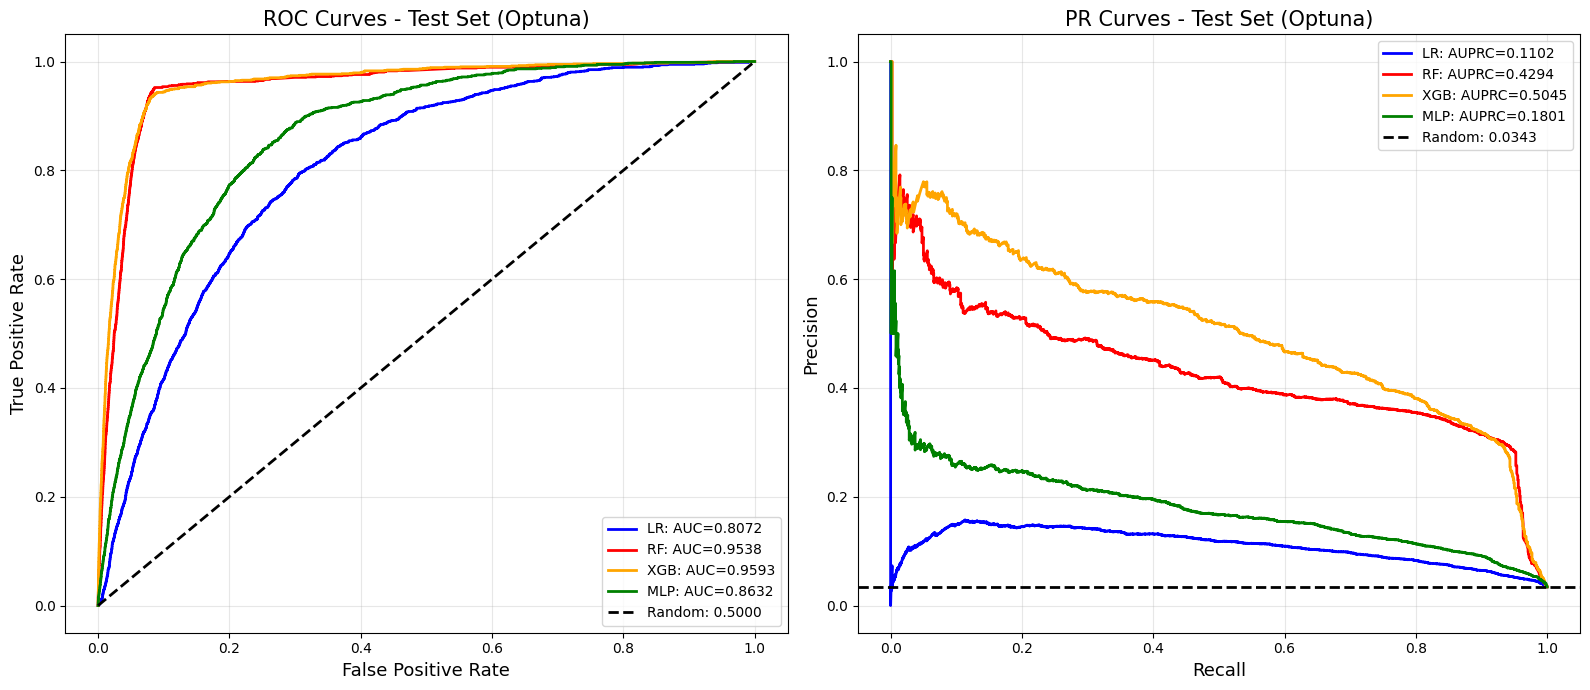

=== Test Set Results (Optuna) ===
Model    AUC  AUPRC    PPV    NPV    MCC Spec@90
   LR 0.8072 0.1102 0.0748 0.9915 0.1774  0.5378
   RF 0.9538 0.4294 0.3571 0.9922 0.5086  0.9305
  XGB 0.9593 0.5045 0.3960 0.9913 0.5285  0.9317
  MLP 0.8632 0.1801 0.1015 0.9929 0.2349  0.6832


In [25]:
colors = {'LR': 'b', 'RF': 'r', 'XGB': 'orange', 'MLP': 'green'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ROC Curves - Test Set
for name, m in optuna_test.items():
    axes[0].plot(m['fpr'], m['tpr'],
                 label=f"{name}: AUC={m['auc']:.4f}",
                 color=colors[name], lw=2)
axes[0].plot([0, 1], [0, 1], 'k--', lw=2, label='Random: 0.5000')
axes[0].set_xlim([-0.05, 1.05])
axes[0].set_ylim([-0.05, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=13)
axes[0].set_ylabel('True Positive Rate', fontsize=13)
axes[0].set_title('ROC Curves - Test Set (Optuna)', fontsize=15)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(alpha=0.3)

# PR Curves - Test Set
baseline = y_test.mean()
for name, m in optuna_test.items():
    axes[1].plot(m['recall_curve'], m['precision_curve'],
                 label=f"{name}: AUPRC={m['auc_prc']:.4f}",
                 color=colors[name], lw=2)
axes[1].axhline(y=baseline, color='k', linestyle='--', lw=2,
                label=f'Random: {baseline:.4f}')
axes[1].set_xlim([-0.05, 1.05])
axes[1].set_ylim([-0.05, 1.05])
axes[1].set_xlabel('Recall', fontsize=13)
axes[1].set_ylabel('Precision', fontsize=13)
axes[1].set_title('PR Curves - Test Set (Optuna)', fontsize=15)
axes[1].legend(loc='upper right', fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OPTUNA_SAVE_DIR}/test_curves.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Summary Table
test_summary = []
for name, m in optuna_test.items():
    test_summary.append({
        'Model': name,
        'AUC': f"{m['auc']:.4f}",
        'AUPRC': f"{m['auc_prc']:.4f}",
        'PPV': f"{m['ppv']:.4f}",
        'NPV': f"{m['npv']:.4f}",
        'MCC': f"{m['mcc']:.4f}",
        'Spec@90': f"{m['spec@90']:.4f}",
    })
print("=== Test Set Results (Optuna) ===")
print(pd.DataFrame(test_summary).to_string(index=False))

## 15. Quick CV (Default Hyperparameters, 5-Fold)

Optuna 없이 기본 하이퍼파라미터로 빠르게 5-Fold CV 수행.
- **실행 조건**: Section 1~9 셀 실행 필요 (Section 8의 Optuna 셀은 스킵 가능, MLP 클래스 셀은 실행 필요)

In [37]:
QUICK_N_SPLITS = 5

quick_kfold = StratifiedKFold(n_splits=QUICK_N_SPLITS, shuffle=True, random_state=SEED_VALUE)

quick_folds = []
for fold_idx, (tr_idx, val_idx) in enumerate(quick_kfold.split(X_train, y_train), 1):
    quick_folds.append({
        'fold': fold_idx,
        'X_tr': X_train[tr_idx],
        'X_val': X_train[val_idx],
        'y_tr': y_train[tr_idx],
        'y_val': y_train[val_idx],
    })
    print(
        f"Fold {fold_idx}: train {len(tr_idx):,} (pos={y_train[tr_idx].sum():.0f}) | "
        f"val {len(val_idx):,} (pos={y_train[val_idx].sum():.0f})"
    )
print(f"\n{len(quick_folds)} folds ready")

Fold 1: train 125,081 (pos=4289) | val 31,271 (pos=1072)
Fold 2: train 125,081 (pos=4288) | val 31,271 (pos=1073)
Fold 3: train 125,082 (pos=4289) | val 31,270 (pos=1072)
Fold 4: train 125,082 (pos=4289) | val 31,270 (pos=1072)
Fold 5: train 125,082 (pos=4289) | val 31,270 (pos=1072)

5 folds ready


In [ ]:
print("=" * 60)
print("LOGISTIC REGRESSION (Default: C=1.0, penalty=l2)")
print("=" * 60)

quick_lr_cv = {}

for f in quick_folds:
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(f['X_tr'])
    X_val = scaler.transform(f['X_val'])

    clf = LogisticRegression(
        random_state=SEED_VALUE,
        solver='liblinear',
        penalty='l2',
        C=1.0,
        class_weight='balanced',
    )
    clf.fit(X_tr, f['y_tr'])
    probs = clf.predict_proba(X_val)[:, 1]

    quick_lr_cv[f['fold']] = compute_metrics(f['y_val'], probs)
    m = quick_lr_cv[f['fold']]
    print(
        f"Fold {f['fold']:2d}: AUC={m['auc']:.4f}  AUPRC={m['auc_prc']:.4f}  "
        f"PPV={m['ppv']:.4f}  NPV={m['npv']:.4f}  MCC={m['mcc']:.4f}"
    )

quick_lr_results = aggregate_cv_metrics(quick_lr_cv)

In [ ]:
print("=" * 60)
print("RANDOM FOREST (Default: n_estimators=300, max_depth=15)")
print("=" * 60)

quick_rf_cv = {}

for f in quick_folds:
    clf = RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        max_features=8,
        random_state=SEED_VALUE,
        class_weight='balanced',
        n_jobs=-1,
    )
    clf.fit(f['X_tr'], f['y_tr'])
    probs = clf.predict_proba(f['X_val'])[:, 1]

    quick_rf_cv[f['fold']] = compute_metrics(f['y_val'], probs)
    m = quick_rf_cv[f['fold']]
    print(
        f"Fold {f['fold']:2d}: AUC={m['auc']:.4f}  AUPRC={m['auc_prc']:.4f}  "
        f"PPV={m['ppv']:.4f}  NPV={m['npv']:.4f}  MCC={m['mcc']:.4f}"
    )

quick_rf_results = aggregate_cv_metrics(quick_rf_cv)

RANDOM FOREST (Default: n_estimators=300, max_depth=15)
Fold  1: AUC=0.9499  AUPRC=0.3982  PPV=0.3038  NPV=0.9962  MCC=0.4981
Fold  2: AUC=0.9570  AUPRC=0.4548  PPV=0.3158  NPV=0.9968  MCC=0.5141
Fold  3: AUC=0.9505  AUPRC=0.4114  PPV=0.3085  NPV=0.9965  MCC=0.5054
Fold  4: AUC=0.9530  AUPRC=0.3939  PPV=0.3117  NPV=0.9968  MCC=0.5106
Fold  5: AUC=0.9552  AUPRC=0.4317  PPV=0.3115  NPV=0.9966  MCC=0.5081


In [ ]:
print("=" * 60)
print("XGBOOST (Default: max_depth=6, lr=0.1)")
print("=" * 60)

quick_xgb_cv = {}

for f in quick_folds:
    neg = (f['y_tr'] == 0).sum()
    pos = (f['y_tr'] == 1).sum()

    clf = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        random_state=SEED_VALUE,
        scale_pos_weight=neg / pos,
        use_label_encoder=False,
        eval_metric='logloss',
    )
    clf.fit(f['X_tr'], f['y_tr'])
    probs = clf.predict_proba(f['X_val'])[:, 1]

    quick_xgb_cv[f['fold']] = compute_metrics(f['y_val'], probs)
    m = quick_xgb_cv[f['fold']]
    print(
        f"Fold {f['fold']:2d}: AUC={m['auc']:.4f}  AUPRC={m['auc_prc']:.4f}  "
        f"PPV={m['ppv']:.4f}  NPV={m['npv']:.4f}  MCC={m['mcc']:.4f}"
    )

quick_xgb_results = aggregate_cv_metrics(quick_xgb_cv)

XGBOOST (Default: max_depth=6, lr=0.1)
Fold  1: AUC=0.9563  AUPRC=0.4775  PPV=0.3467  NPV=0.9943  MCC=0.5191
Fold  2: AUC=0.9599  AUPRC=0.5071  PPV=0.3628  NPV=0.9951  MCC=0.5401
Fold  3: AUC=0.9598  AUPRC=0.4785  PPV=0.3509  NPV=0.9939  MCC=0.5192
Fold  4: AUC=0.9587  AUPRC=0.4670  PPV=0.3465  NPV=0.9944  MCC=0.5199
Fold  5: AUC=0.9613  AUPRC=0.4669  PPV=0.3509  NPV=0.9945  MCC=0.5242


In [39]:
print("=" * 60)
print("MLP (Default: hidden=256, dropout=0.3, lr=1e-3)")
print("=" * 60)

quick_mlp_cv = {}

for f in quick_folds:
    probs = train_mlp_fold(
        f['X_tr'], f['y_tr'], f['X_val'], f['y_val'],
        hidden_dim=256, dropout=0.3, lr=1e-3, epochs=20,
    )

    quick_mlp_cv[f['fold']] = compute_metrics(f['y_val'], probs)
    m = quick_mlp_cv[f['fold']]
    print(
        f"Fold {f['fold']:2d}: AUC={m['auc']:.4f}  AUPRC={m['auc_prc']:.4f}  "
        f"PPV={m['ppv']:.4f}  NPV={m['npv']:.4f}  MCC={m['mcc']:.4f}"
    )

quick_mlp_results = aggregate_cv_metrics(quick_mlp_cv)

MLP (Default: hidden=256, dropout=0.3, lr=1e-3)
Fold  1: AUC=0.8587  AUPRC=0.1693  PPV=0.1040  NPV=0.9927  MCC=0.2384
Fold  2: AUC=0.8624  AUPRC=0.1829  PPV=0.1118  NPV=0.9914  MCC=0.2451
Fold  3: AUC=0.8593  AUPRC=0.1647  PPV=0.0991  NPV=0.9932  MCC=0.2318
Fold  4: AUC=0.8615  AUPRC=0.1646  PPV=0.1073  NPV=0.9927  MCC=0.2440
Fold  5: AUC=0.8607  AUPRC=0.1823  PPV=0.1025  NPV=0.9937  MCC=0.2400


In [23]:
quick_results = {
    'LR': quick_lr_results,
    'RF': quick_rf_results,
    'XGB': quick_xgb_results,
    # 'MLP': quick_mlp_results,
}

print("=== Quick CV Summary (5-Fold, Default Params) ===\n")
for name, r in quick_results.items():
    print(f"{name}: AUC={r['mean_auc']:.4f} ({r['l_CI']:.4f}-{r['h_CI']:.4f})  "
          f"AUPRC={r['mean_auc_prc']:.4f} ({r['auprc_l_CI']:.4f}-{r['auprc_h_CI']:.4f})")

# Summary table
quick_summary = []
for name, r in quick_results.items():
    quick_summary.append({
        'Model': name,
        'AUC': f"{r['mean_auc']:.4f} ({r['l_CI']:.4f}-{r['h_CI']:.4f})",
        'AUPRC': f"{r['mean_auc_prc']:.4f} ({r['auprc_l_CI']:.4f}-{r['auprc_h_CI']:.4f})",
        'PPV': f"{r['ppv']:.4f}",
        'NPV': f"{r['npv']:.4f}",
        'MCC': f"{r['mcc']:.4f}",
        'Spec@90': f"{r['spec@90']:.4f}",
    })
print(f"\n{pd.DataFrame(quick_summary).to_string(index=False)}")

=== Quick CV Summary (5-Fold, Default Params) ===

LR: AUC=0.8049 (0.8013-0.8085)  AUPRC=0.1063 (0.1025-0.1101)
RF: AUC=0.9531 (0.9493-0.9569)  AUPRC=0.4180 (0.3866-0.4494)
XGB: AUC=0.9592 (0.9569-0.9615)  AUPRC=0.4794 (0.4590-0.4998)

Model                    AUC                  AUPRC    PPV    NPV    MCC Spec@90
   LR 0.8049 (0.8013-0.8085) 0.1063 (0.1025-0.1101) 0.0752 0.9917 0.1792  0.5480
   RF 0.9531 (0.9493-0.9569) 0.4180 (0.3866-0.4494) 0.3103 0.9966 0.5073  0.9303
  XGB 0.9592 (0.9569-0.9615) 0.4794 (0.4590-0.4998) 0.3516 0.9944 0.5245  0.9341


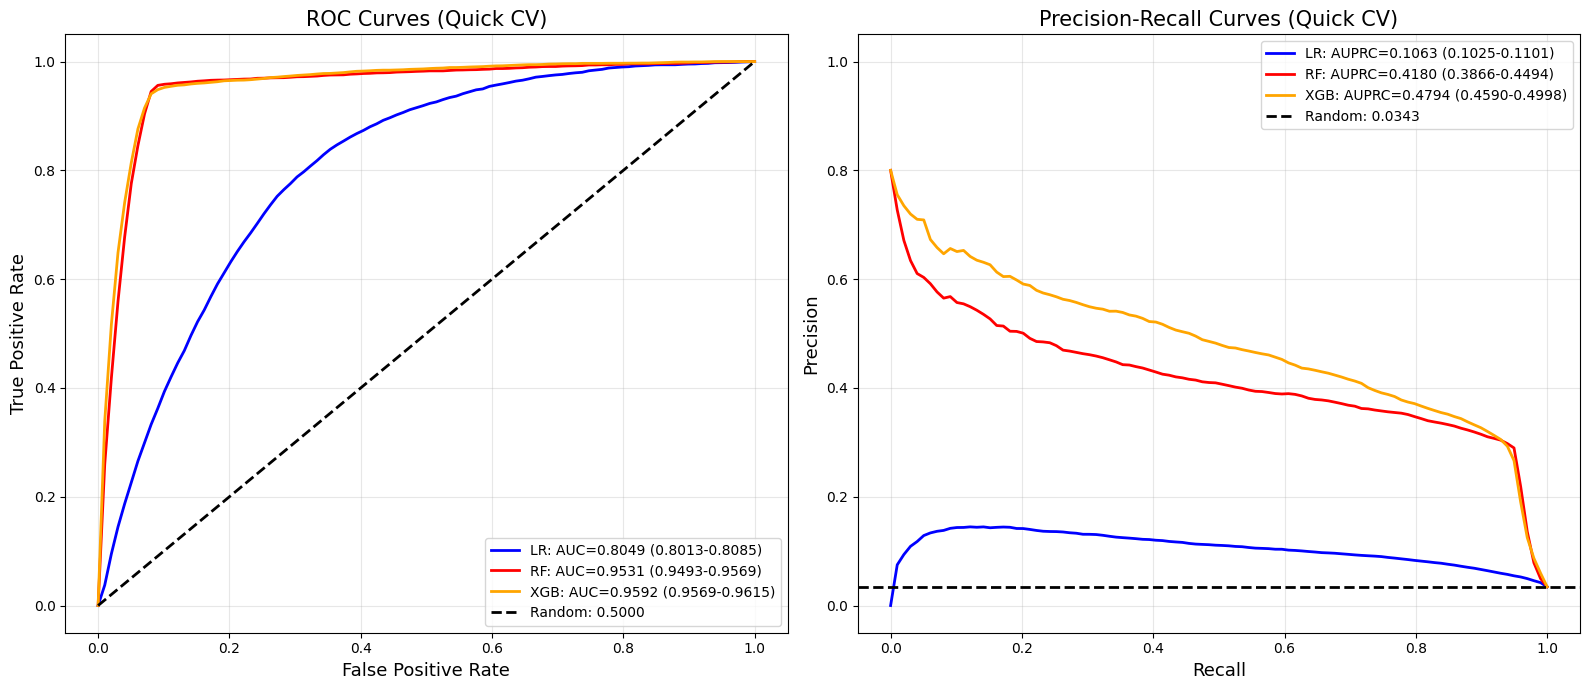

In [24]:
colors = {'LR': 'b', 'RF': 'r', 'XGB': 'orange', 'MLP': 'green'}

# ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
mean_fpr = np.linspace(0, 1, 100)

for name, result in quick_results.items():
    axes[0].plot(mean_fpr, result['tpr'],
                 label=f"{name}: AUC={result['mean_auc']:.4f} ({result['l_CI']:.4f}-{result['h_CI']:.4f})",
                 color=colors[name], lw=2)

axes[0].plot([0, 1], [0, 1], 'k--', lw=2, label='Random: 0.5000')
axes[0].set_xlim([-0.05, 1.05])
axes[0].set_ylim([-0.05, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=13)
axes[0].set_ylabel('True Positive Rate', fontsize=13)
axes[0].set_title('ROC Curves (Quick CV)', fontsize=15)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(alpha=0.3)

# PR Curves
baseline_ratio = df[TARGET_COL].mean()
mean_recall = np.linspace(0, 1, 100)

for name, result in quick_results.items():
    axes[1].plot(mean_recall, result['mean_prc'],
                 label=f"{name}: AUPRC={result['mean_auc_prc']:.4f} ({result['auprc_l_CI']:.4f}-{result['auprc_h_CI']:.4f})",
                 color=colors[name], lw=2)

axes[1].axhline(y=baseline_ratio, color='k', linestyle='--', lw=2,
                label=f'Random: {baseline_ratio:.4f}')
axes[1].set_xlim([-0.05, 1.05])
axes[1].set_ylim([-0.05, 1.05])
axes[1].set_xlabel('Recall', fontsize=13)
axes[1].set_ylabel('Precision', fontsize=13)
axes[1].set_title('Precision-Recall Curves (Quick CV)', fontsize=15)
axes[1].legend(loc='upper right', fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('quick_cv_curves.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## Quick CV - Final Model Training & Test Evaluation

Default params로 전체 train set에 최종 학습 → test set 평가 → 모델 객체 저장

In [ ]:
QUICK_SAVE_DIR = '../models/quick'
os.makedirs(QUICK_SAVE_DIR, exist_ok=True)

print("=" * 60)
print("FINAL MODEL TRAINING (Default Params)")
print("=" * 60)

# ---- 1) Logistic Regression ----
scaler_lr = StandardScaler()
X_train_lr = scaler_lr.fit_transform(X_train)
X_test_lr = scaler_lr.transform(X_test)

final_lr = LogisticRegression(
    random_state=SEED_VALUE,
    solver='liblinear',
    penalty='l2',
    C=1.0,
    class_weight='balanced',
)
final_lr.fit(X_train_lr, y_train)
lr_test_probs = final_lr.predict_proba(X_test_lr)[:, 1]
lr_test_m = compute_metrics(y_test, lr_test_probs)

joblib.dump(final_lr, f'{QUICK_SAVE_DIR}/lr_model.joblib')
joblib.dump(scaler_lr, f'{QUICK_SAVE_DIR}/lr_scaler.joblib')
print(f"LR  - Test AUC={lr_test_m['auc']:.4f}  AUPRC={lr_test_m['auc_prc']:.4f}  MCC={lr_test_m['mcc']:.4f}")

# ---- 2) Random Forest ----
final_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    max_features=8,
    random_state=SEED_VALUE,
    class_weight='balanced',
    n_jobs=-1,
)
final_rf.fit(X_train, y_train)
rf_test_probs = final_rf.predict_proba(X_test)[:, 1]
rf_test_m = compute_metrics(y_test, rf_test_probs)

joblib.dump(final_rf, f'{QUICK_SAVE_DIR}/rf_model.joblib')
print(f"RF  - Test AUC={rf_test_m['auc']:.4f}  AUPRC={rf_test_m['auc_prc']:.4f}  MCC={rf_test_m['mcc']:.4f}")

# ---- 3) XGBoost ----
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

final_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    random_state=SEED_VALUE,
    scale_pos_weight=neg / pos,
    use_label_encoder=False,
    eval_metric='logloss',
)
final_xgb.fit(X_train, y_train)
xgb_test_probs = final_xgb.predict_proba(X_test)[:, 1]
xgb_test_m = compute_metrics(y_test, xgb_test_probs)

joblib.dump(final_xgb, f'{QUICK_SAVE_DIR}/xgb_model.joblib')
print(f"XGB - Test AUC={xgb_test_m['auc']:.4f}  AUPRC={xgb_test_m['auc_prc']:.4f}  MCC={xgb_test_m['mcc']:.4f}")

# ---- 4) MLP ----
scaler_mlp = StandardScaler()
X_train_mlp = scaler_mlp.fit_transform(X_train)
X_test_mlp = scaler_mlp.transform(X_test)

X_tr_t = torch.tensor(X_train_mlp, dtype=torch.float32)
y_tr_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_te_t = torch.tensor(X_test_mlp, dtype=torch.float32)

final_mlp = MLP(in_dim=X_tr_t.shape[1], hidden_dim=256, dropout=0.3)

pos_weight = torch.tensor([neg / max(pos, 1)], dtype=torch.float32)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(final_mlp.parameters(), lr=1e-3, weight_decay=1e-5)

final_mlp.train()
for epoch in range(20):
    perm = torch.randperm(len(X_tr_t))
    for i in range(0, len(X_tr_t), 512):
        idx = perm[i:i + 512]
        optimizer.zero_grad()
        loss = criterion(final_mlp(X_tr_t[idx]), y_tr_t[idx])
        loss.backward()
        optimizer.step()

final_mlp.eval()
with torch.no_grad():
    mlp_test_probs = torch.sigmoid(final_mlp(X_te_t)).numpy().ravel()
mlp_test_m = compute_metrics(y_test, mlp_test_probs)

torch.save({
    'model_state_dict': final_mlp.state_dict(),
    'params': {'hidden_dim': 256, 'dropout': 0.3, 'lr': 1e-3},
    'in_dim': X_tr_t.shape[1],
}, f'{QUICK_SAVE_DIR}/mlp_model.pt')
joblib.dump(scaler_mlp, f'{QUICK_SAVE_DIR}/mlp_scaler.joblib')
print(f"MLP - Test AUC={mlp_test_m['auc']:.4f}  AUPRC={mlp_test_m['auc_prc']:.4f}  MCC={mlp_test_m['mcc']:.4f}")

# ---- Aggregate test results ----
quick_test = {'LR': lr_test_m, 'RF': rf_test_m, 'XGB': xgb_test_m, 'MLP': mlp_test_m}

for name, m in quick_test.items():
    with open(f'{QUICK_SAVE_DIR}/{name}_test_metrics.json', 'w') as f:
        json.dump({k: float(v) for k, v in m.items() if isinstance(v, (int, float, np.floating))}, f, indent=2)

print(f"\nAll models and metrics saved to {QUICK_SAVE_DIR}/")

In [ ]:
colors = {'LR': 'b', 'RF': 'r', 'XGB': 'orange', 'MLP': 'green'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ROC Curves - Test Set
for name, m in quick_test.items():
    axes[0].plot(m['fpr'], m['tpr'],
                 label=f"{name}: AUC={m['auc']:.4f}",
                 color=colors[name], lw=2)
axes[0].plot([0, 1], [0, 1], 'k--', lw=2, label='Random: 0.5000')
axes[0].set_xlim([-0.05, 1.05])
axes[0].set_ylim([-0.05, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=13)
axes[0].set_ylabel('True Positive Rate', fontsize=13)
axes[0].set_title('ROC Curves - Test Set (Quick CV)', fontsize=15)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(alpha=0.3)

# PR Curves - Test Set
baseline = y_test.mean()
for name, m in quick_test.items():
    axes[1].plot(m['recall_curve'], m['precision_curve'],
                 label=f"{name}: AUPRC={m['auc_prc']:.4f}",
                 color=colors[name], lw=2)
axes[1].axhline(y=baseline, color='k', linestyle='--', lw=2,
                label=f'Random: {baseline:.4f}')
axes[1].set_xlim([-0.05, 1.05])
axes[1].set_ylim([-0.05, 1.05])
axes[1].set_xlabel('Recall', fontsize=13)
axes[1].set_ylabel('Precision', fontsize=13)
axes[1].set_title('PR Curves - Test Set (Quick CV)', fontsize=15)
axes[1].legend(loc='upper right', fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{QUICK_SAVE_DIR}/test_curves.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Summary Table
test_summary = []
for name, m in quick_test.items():
    test_summary.append({
        'Model': name,
        'AUC': f"{m['auc']:.4f}",
        'AUPRC': f"{m['auc_prc']:.4f}",
        'PPV': f"{m['ppv']:.4f}",
        'NPV': f"{m['npv']:.4f}",
        'MCC': f"{m['mcc']:.4f}",
        'Spec@90': f"{m['spec@90']:.4f}",
    })
print("=== Test Set Results (Quick CV) ===")
print(pd.DataFrame(test_summary).to_string(index=False))

In [ ]:
for model_name, result in all_results.items():
    filename = f'model_{model_name}_mimiciv_CI.json'

    metrics_to_save = {
        'mean_auc': float(result['mean_auc']),
        'std_auc': float(result['std_auc']),
        'l_CI': float(result['l_CI']),
        'h_CI': float(result['h_CI']),
        'mean_auc_prc': float(result['mean_auc_prc']),
        'auprc_l_CI': float(result['auprc_l_CI']),
        'auprc_h_CI': float(result['auprc_h_CI']),
        'ppv': float(result['ppv']),
        'p_l_CI': float(result['p_l_CI']),
        'p_h_CI': float(result['p_h_CI']),
        'npv': float(result['npv']),
        'mcc': float(result['mcc']),
        'spec@90': float(result['spec@90']),
        'recall': float(result['rec_single']),
        'r_l_CI': float(result['r_l_CI']),
        'r_h_CI': float(result['r_h_CI']),
        'n_total': int(len(df)),
        'n_positive': int(df[TARGET_COL].sum()),
        'n_negative': int(len(df) - df[TARGET_COL].sum())
    }

    with open(filename, 'w') as f:
        json.dump(metrics_to_save, f, indent=2)

    print(f"Saved: {filename}")

## 14. Results Summary Table

In [25]:
summary_data = []
for model_name, result in all_results.items():
    summary_data.append({
        'Model': model_name,
        'AUC': f"{result['mean_auc']:.4f} ({result['l_CI']:.4f}-{result['h_CI']:.4f})",
        'AUPRC': f"{result['mean_auc_prc']:.4f} ({result['auprc_l_CI']:.4f}-{result['auprc_h_CI']:.4f})",
        'PPV': f"{result['ppv']:.4f}",
        'NPV': f"{result['npv']:.4f}",
        'MCC': f"{result['mcc']:.4f}",
        'Spec@90': f"{result['spec@90']:.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print(f"\n=== Results Summary (MIMIC-IV, n={len(df):,}) ===")
print(summary_df.to_string(index=False))

NameError: name 'all_results' is not defined